In [1]:
#packages
import requests
import pandas as pd
import json
from glob import glob
from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px

import geopandas as gpd

# STEP A — PCA on socioeconomic variables (tract-level)

Procedure:

    • Standardize variables
    • Run PCA
    • Keep PC1–PC3 (likely ≥60–80% variance)
    • Extract tract-level PCA scores

Figures:

    • Scree plot
    • Loading plot (which variables drive each PC)
    • Table of PCA scores by tract

In [2]:
#pulling standardized socioeconomic variables
tract_socioeconomic = pd.read_csv('data_processed/PCA_data/tract_socioeconomic.csv')
tract_socioeconomic['TRACT'] = tract_socioeconomic['TRACT'].astype(str).str.zfill(6)

In [3]:
duplicate_counts = tract_socioeconomic['TRACT'].duplicated().sum()
print("Number of duplicate TRACT values:", duplicate_counts)


Number of duplicate TRACT values: 0


In [4]:
# show missing counts per column
print(tract_socioeconomic.isna().sum().sort_values(ascending=False).head(20))

# fraction missing per column
print((tract_socioeconomic.isna().mean()).sort_values(ascending=False).head(20))

# how many rows have any missing
print("Rows with any NaN:", tract_socioeconomic.isna().any(axis=1).sum(), " / ", len(tract_socioeconomic))

# optionally inspect rows with missing
missing_rows = tract_socioeconomic[tract_socioeconomic.isna().any(axis=1)]
missing_rows.head()


median_household_income                     17
american_indian_alaska_native                0
pct_over65                                   0
pct_with_disability                          0
population_below_50pct_poverty               0
population_civilian_noninstitutionalized     0
population_over65                            0
population_with_disability                   0
rent_30_to_34_pct_income                     0
rent_35_to_39_pct_income                     0
rent_40_to_49_pct_income                     0
rent_50_plus_pct_income                      0
renter_occupied_housing_units                0
some_other_race                              0
total_households_in_internet_table           0
total_households_vehicle_data                0
total_housing_units                          0
total_population                             0
total_renters                                0
two_or_more_races                            0
dtype: int64
median_household_income                     0.0

,american_indian_alaska_native,asian_alone,bachelors_degree,black_alone,female_65_66,female_67_69,female_70_74,female_75_79,female_80_84,female_85_plus,...,renter_occupied_housing_units,some_other_race,total_households_in_internet_table,total_households_vehicle_data,total_housing_units,total_population,total_renters,two_or_more_races,white_alone,TRACT
50,-0.147879,-0.446266,-1.300920,-0.709459,-1.107907,-0.938943,-0.940776,-1.182921,-1.069690,-0.429363,...,-1.119653,-0.681098,-2.036002,-2.036002,-2.036002,-1.921768,-1.119653,-0.941444,-1.530325,920302
55,-0.116633,-0.414854,-1.296767,-0.195765,-1.107907,-0.751484,-1.258439,-1.129012,-1.069690,-0.797195,...,-1.243475,-0.603369,-2.370684,-2.370684,-2.370684,-1.324922,-1.243475,-0.828099,-1.163019,980000
137,-0.168709,-0.446266,-1.344529,-0.913633,-1.107907,-1.238878,-1.298147,-1.182921,-1.069690,-0.797195,...,-1.243475,-0.681098,-2.370684,-2.370684,-2.370684,-2.253472,-1.243475,-1.025404,-1.794840,990100
197,-0.038520,-0.434843,-0.308291,-0.851729,-0.542037,-0.639008,-0.398100,2.177462,0.714825,8.994126,...,0.158291,-0.681098,-0.834737,-0.834737,-0.834737,-1.053678,0.158291,-0.912058,-0.390032,003108
301,-0.168709,-0.446266,-1.344529,-0.913633,-1.107907,-1.238878,-1.298147,-1.182921,-1.069690,-0.797195,...,-1.243475,-0.681098,-2.370684,-2.370684,-2.370684,-2.253472,-1.243475,-1.025404,-1.794840,980100


In [5]:
#Dropping the tracts with NAs
tract_socioeconomic_clean = tract_socioeconomic.dropna()

#Keeping derived calculations only
ses_vars = [
    "median_household_income",
    "pct_below_50pct_poverty",
    "pct_no_vehicle",
    "pct_renters_cost_burdened",
    "pct_over65",
    "pct_with_disability",
    "pct_nonwhite"
]

In [6]:
# Separate features and ID
X = tract_socioeconomic_clean.drop(columns=['TRACT'])  
X = X[ses_vars] 
tract_ids = tract_socioeconomic_clean['TRACT']      


## Scree Plot

To see how many PCs to keep

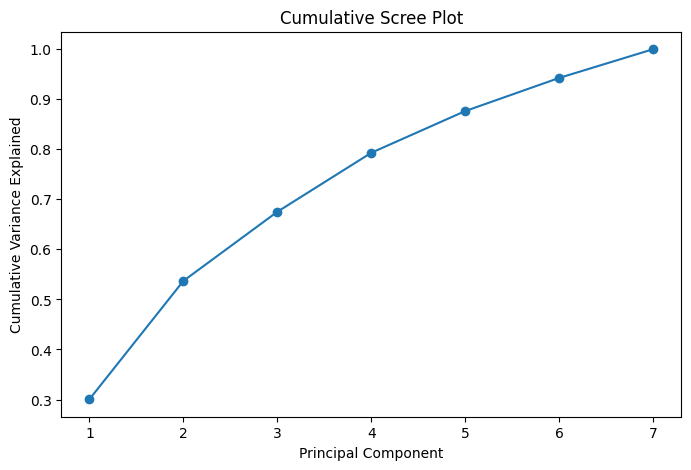

In [7]:
pca = PCA(n_components=7)
pca_scores = pca.fit_transform(X)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_.cumsum(),
         marker='o')

plt.xticks(range(1, len(pca.explained_variance_ratio_)+1))
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance Explained")
plt.title("Cumulative Scree Plot")
plt.show()

PC1: ~32%

PC2: ~18% (cumulative ~50%)

PC3: ~16% (cumulative ~66%)

PC4: ~13% (cumulative ~79%)

PC5: ~10% (cumulative ~89%)

PC6: ~8% (cumulative ~97%)

PC7: the rest

PC 1-3 is probably sufficient

## Running PCA for 3 components

In [8]:
# Keeping first three principle components
pca = PCA(n_components=3)
pca_scores = pca.fit_transform(X)

In [9]:
# Turn PCA scores into a dataframe
socioeconomic_tract_pca_scores = pd.DataFrame(
    pca_scores,
    columns=['PC1', 'PC2', 'PC3']
)
socioeconomic_tract_pca_scores['TRACT'] = tract_ids.values   # add back id

# Get PCA loadings
socioeconomic_tract_loadings = pd.DataFrame(
    pca.components_.T,     # each row = variable, each column = PC
    index=X.columns,
    columns=['PC1', 'PC2', 'PC3']
)



In [10]:
fig = px.scatter_3d(
    socioeconomic_tract_pca_scores,
    x="PC1",
    y="PC2",
    z="PC3",
    hover_name="TRACT",  
    opacity=0.5
)

fig.update_layout(
    title="Interactive 3D PCA Scatterplot of Census Tracts",
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    )
)

fig.show()

PCA transforms correlated socioeconomic variables into a smaller number of independent components PC1, PC2, PC3.

tract_socioeconomic_pca: Displays tract-level PCA scores

PCA Scores: where does each tract lie along these abstract socioeconomic axes

Loadings: which variables define each principal component (ie which pattern does PC1, PC2, and PC3 represent). The are weights linking original variables to each principal component.

## Loadings Interpretation:

### PC1

PC1 is the “structural disadvantage” axis.
High scores = younger, poorer, more racially diverse communities with higher disability rates and more rent burden.
Low scores = older, wealthier, mostly white communities with low poverty.

### PC2

younger, higher-income but higher-disability communities
loads positively on income and disability, negatively on age, poverty, and no vehicle.

### PC3

high PC3: low vehicle access, moderate disability, low rent burden
Low PC3: high rent burden + low disability + better vehicle access
vehicle access vs rent burden (urban pressure axis)

# STEP B — Cluster census tracts using PCA scores

Use k-means or hierarchical clustering.

Your advisor wants:

    • Cluster tracts based on PC1, PC2, PC3 scores
    • THEN examine outage metrics within each cluster

Output per cluster:

    • Socioeconomic profile (low-income, old housing, rural, etc.)
    • Average outage frequency
    • Average outage duration
    • Weather exposure metrics
    
This gives us: which types of communities experience which outages?

## Choose k (number of clusters)
Via:
- elbow method
- silhouette score

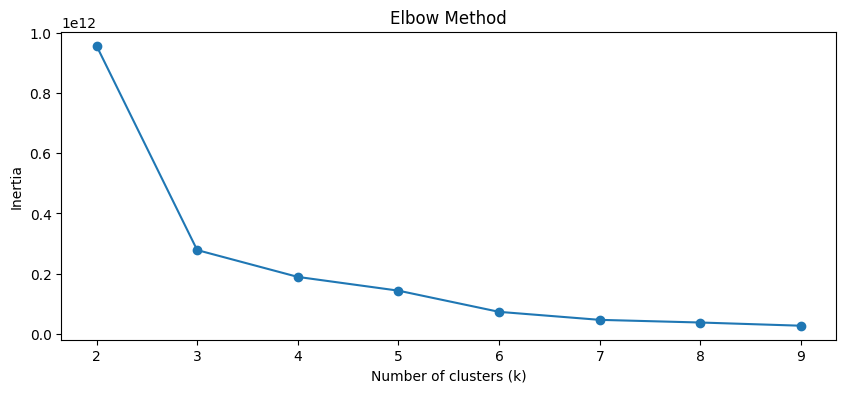

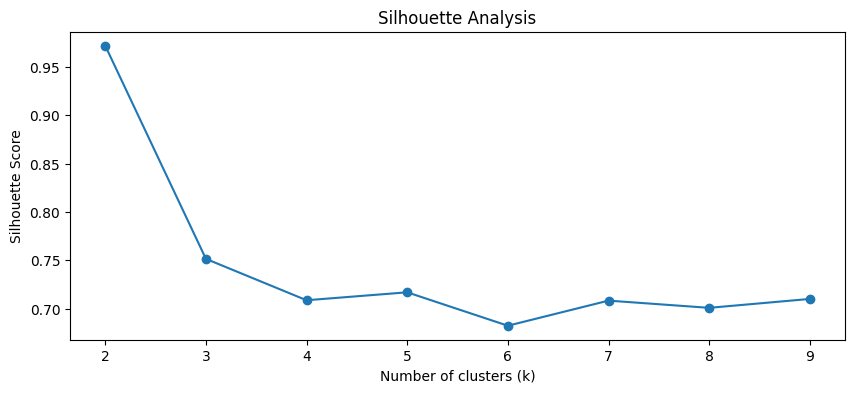

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

Ks = range(2, 10)
inertias = []
silhouettes = []

for k in Ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(socioeconomic_tract_pca_scores)
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(socioeconomic_tract_pca_scores, labels))

# Plot elbow
plt.figure(figsize=(10,4))
plt.plot(Ks, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# Plot silhouette
plt.figure(figsize=(10,4))
plt.plot(Ks, silhouettes, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

Choosing k = 3

- Where elbow is most visible before diminishing returns begin
- Has a higher silhouette score than k = 4, 5, 6
    - For silhouette score, it's highest at k = 2, but 2 clusters might oversimpliofy the data

## Run clustering (k-means / hierarchical)

In [12]:
best_k = 4

kmeans = KMeans(n_clusters=best_k, random_state=42)
socioeconomic_tract_pca_scores['cluster'] = kmeans.fit_predict(socioeconomic_tract_pca_scores)

## Characterize each cluster

Using the unscaled, real socioeconomic variables.

In [13]:
#pulling unscaled socioeconomic variables
tract_socioeconomic_unscaled = pd.read_csv('data_processed/PCA_data/tract_socioeconomic_unscaled.csv')
tract_socioeconomic_unscaled['TRACT'] = tract_socioeconomic_unscaled['TRACT'].astype(str).str.zfill(6)

df = tract_socioeconomic_unscaled.merge(socioeconomic_tract_pca_scores[['TRACT','cluster']], on='TRACT')

socioeconomic_cluster_profiles = df.groupby('cluster')[ses_vars].mean()


It does not seem like NC census tracts fall into sharply distinct socioeconomic groups with these socioeconomic variables. So I instead want to identify SES outliers with PCA Distance. These would be socioeconomic "extreme" tracts.

## Identify standout tracts directly using PCA scores and distances

### Identify SES Outliers Using PCA Distance

In [14]:
pc_df = socioeconomic_tract_pca_scores[['PC1','PC2','PC3']].copy()
pc_df['TRACT'] = socioeconomic_tract_pca_scores['TRACT']

pc_df['distance'] = np.sqrt(pc_df['PC1']**2 + pc_df['PC2']**2 + pc_df['PC3']**2)

#Identifying 20 "outliers"
pc_df.nlargest(20, 'distance')


,PC1,PC2,PC3,TRACT,distance
108,-7.320539,-8.637300,9.460558,020307,14.754504
1283,-0.902097,-4.028337,7.467058,010801,8.532188
733,2.843818,-5.519190,4.702145,011500,7.788384
122,-4.562505,-3.204884,-1.146835,020504,5.692360
93,1.678139,-4.108358,3.533165,950602,5.672567
1258,-2.928944,-3.549752,-3.067714,950303,5.530851
127,-4.577005,-2.963095,-0.483016,020512,5.473775
124,-3.563949,-3.152843,-2.029694,020508,5.173182
732,4.971027,-0.927759,0.445851,011400,5.076478
1512,-1.290573,4.551365,1.607756,021007,4.996537


### Identify extremes along individual SES axes

In [15]:
#Finding extremes along individual SES axes
pc_df.sort_values('PC1').head(10)  # most disadvantaged
pc_df.sort_values('PC1').tail(10)  # most advantaged

pc_df.sort_values('PC2')           # seniors with mobility constraints
pc_df.sort_values('PC3')           # older suburban stability vs rent pressure


,PC1,PC2,PC3,TRACT,distance
1258,-2.928944,-3.549752,-3.067714,950303,5.530851
1145,-1.527986,-0.790609,-2.854180,005720,3.332588
935,-1.194822,-1.148955,-2.630427,061604,3.109154
279,-0.381366,-3.275718,-2.579954,970401,4.187114
804,-0.131272,-1.549460,-2.478510,016010,2.925931
...,...,...,...,...,...
93,1.678139,-4.108358,3.533165,950602,5.672567
1147,-1.046327,-1.958780,3.936466,005722,4.519666
733,2.843818,-5.519190,4.702145,011500,7.788384
1283,-0.902097,-4.028337,7.467058,010801,8.532188


### Use hierarchical clustering (Ward’s method)

Hierarchical clustering can reveal:
2 clusters at the top (wealth vs disadvantage), then splits into smaller subgroups, no assumption of spherical boundaries

And the dendrogram helps tell a story.

Ward's method merges tracts into clusters by minimizing within-group variance. The height of each merge reflects how different two groups are.

In [16]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

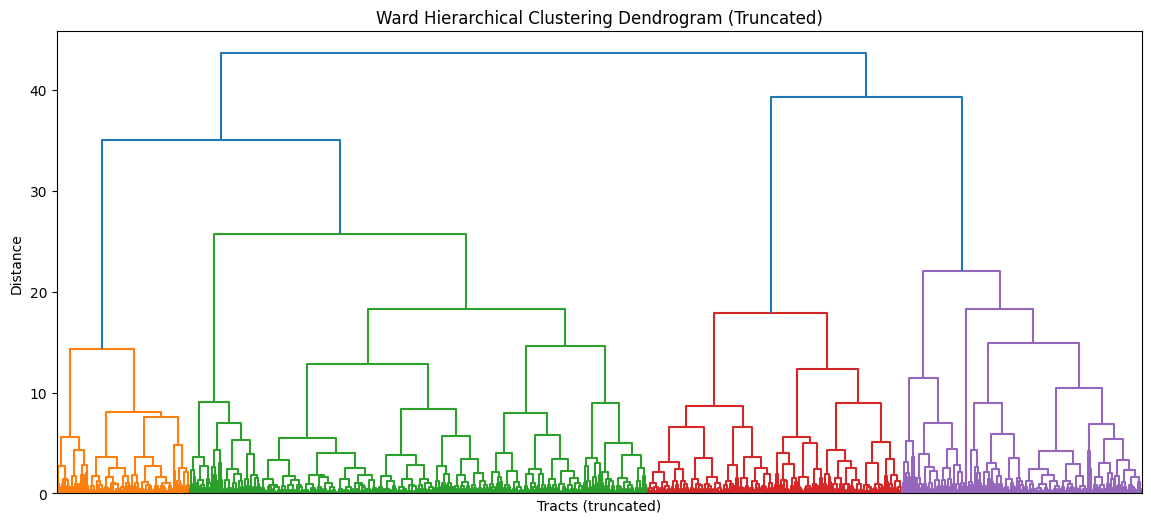

In [17]:
# Use the PCA scores for clustering
X = socioeconomic_tract_pca_scores[['PC1', 'PC2', 'PC3']].reset_index(drop=True)

# Standardize (good practice for hierarchical clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

tract_ids = socioeconomic_tract_pca_scores['TRACT'].astype(str).reset_index(drop=True)

# Compute hierarchical clustering using Ward's method
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    truncate_mode='level',  # show only top hierarchical structure
    p=30,                   # number of leaf nodes to show
    no_labels=True,
)
plt.title("Ward Hierarchical Clustering Dendrogram (Truncated)")
plt.xlabel("Tracts (truncated)")
plt.ylabel("Distance")
plt.show()

In [18]:
labels = fcluster(Z, 4, criterion='maxclust')
socioeconomic_tract_pca_scores['hc_cluster'] = labels

cluster_profiles = (
    tract_socioeconomic_clean
    .merge(socioeconomic_tract_pca_scores[['TRACT','hc_cluster']], on='TRACT')
    .groupby('hc_cluster')[ses_vars]
    .mean()
)
print(cluster_profiles)


            median_household_income  pct_below_50pct_poverty  pct_no_vehicle  \
hc_cluster                                                                     
1                          1.088562                -0.643750       -0.423729   
2                          0.309365                -0.409993       -0.364069   
3                         -0.667192                 0.867478       -0.265112   
4                         -0.485395                 0.230670        1.231035   

            pct_renters_cost_burdened  pct_over65  pct_with_disability  \
hc_cluster                                                               
1                           -0.780356   -0.778547             0.989632   
2                            0.128097    0.382624            -0.367598   
3                            0.611427   -0.543276             0.333451   
4                           -0.428455    0.320098            -0.131344   

            pct_nonwhite  
hc_cluster                
1               0.16

Looks like Ward's method tells us more useful information compared to K Means.

Note: these are Z-scores because SES variables were standardized, so positive = higher-than-average, negative = lower-than-average.

Cluster 1: High-income, older, white, low-need communities
- Very high income (+1.09)
- Very low poverty (–0.64)
- Very low rent burden (–0.78)
- Very few seniors (–0.78) ← younger than average
- Low no-vehicle rate (–0.42) → high car access
- Low disability? Nope → high disability (+0.99)
- Slightly nonwhite (+0.17)

Interpretation:
This cluster looks like affluent but high-disability communities — which is interesting. These areas are high-income, low-poverty, and highly mobile, but disability rates are unusually high for such advantaged places.

Could be retirement-destination suburbs or affluent but medically vulnerable areas.

Cluster 2: Older, white, moderate-income, low-disability suburbs
- Moderately high income (+0.31)
- Low poverty (–0.41)
- Older population (+0.38)
- Low disability (–0.37)
- Very white (–0.57)
- Low no-vehicle rate (–0.36)
- Slightly higher rent burden (+0.13)

Interpretation:
This is your classic suburban stability cluster:
Older, white, low-poverty, moderate-income, car-oriented neighborhoods with relatively low physical vulnerability.

Cluster 3: High-poverty, high-nonwhite, rent-burdened communities
- Low income (–0.67)
- High deep poverty (+0.87)
- High rent burden (+0.61)
- High nonwhite share (+0.95)
- Low vehicle access (–0.27)
- High disability (+0.33)
- Slightly younger (–0.54)

Interpretation:
These are structurally disadvantaged urban neighborhoods:
High poverty, high rent burden, more nonwhite, higher disability, fewer seniors, and lower car access.

This cluster aligns with PC1 = structural disadvantage axis.

Cluster 4: Low-income, low-vehicle, mixed-vulnerability (older but low disability)
- Below-average income (–0.49)
- Moderately high poverty (+0.23)
- Extremely high no-vehicle rate (+1.23)
- Moderately older population (+0.32)
- Low disability (–0.13)
- Low rent burden (–0.43)
- Near-average racial composition (–0.06)

Interpretation:
This one is the trickiest because it mixes traits: 
Older adults
Very low vehicle access
Low disability
Low rent burden
Low-income

This cluster looks like older, low-income, transit-dependent communities where housing costs are not the primary burden. Think older urban apartment areas, maybe fixed-income seniors who rely on transit, but without the extreme rent burden typical of Cluster 3.

### Map PCs or SES variables directly

Because clusters are mild, mapping PC1–PC3 across NC may tell a richer story than clustering.

For example:

PC1 map: structural disadvantage gradient

PC2 map: mobility-limited aging populations

PC3 map: older suburban stable areas vs younger cost-burdened areas

map 4: Ward clusters

In [19]:
tract_geo = gpd.read_file("data_raw/tl_2022_37_tract")
tract_geo['TRACT'] = tract_geo['GEOID'].str[-6:]  # extract 6-digit tract code
tract_geo = tract_geo.to_crs(epsg=4326)

# Ensure TRACT columns are strings and zero-padded to 6 digits
socioeconomic_tract_pca_scores['TRACT'] = socioeconomic_tract_pca_scores['TRACT'].astype(str).str.zfill(6)
tract_geo['TRACT'] = tract_geo['TRACT'].astype(str).str.zfill(6)

# Merge GeoDataFrame with PCA+cluster data
gdf = tract_geo.merge(
    socioeconomic_tract_pca_scores[['TRACT','PC1','PC2','PC3','hc_cluster']],
    on='TRACT',
    how='left'
)

# Drop tracts missing PCA values (if any)
gdf = gdf.dropna(subset=['PC1','PC2','PC3'])

# Ensure GeoDataFrame is in WGS84 (plotly expects EPSG:4326)
gdf = gdf.to_crs(epsg=4326)

# Save an output GeoJSON for other apps / backup
gdf.to_file("data_processed/socioeconomic_tracts_with_pca_and_clusters.geojson", driver="GeoJSON")
print("Saved tracts_with_pca_and_clusters.geojson")

Saved tracts_with_pca_and_clusters.geojson


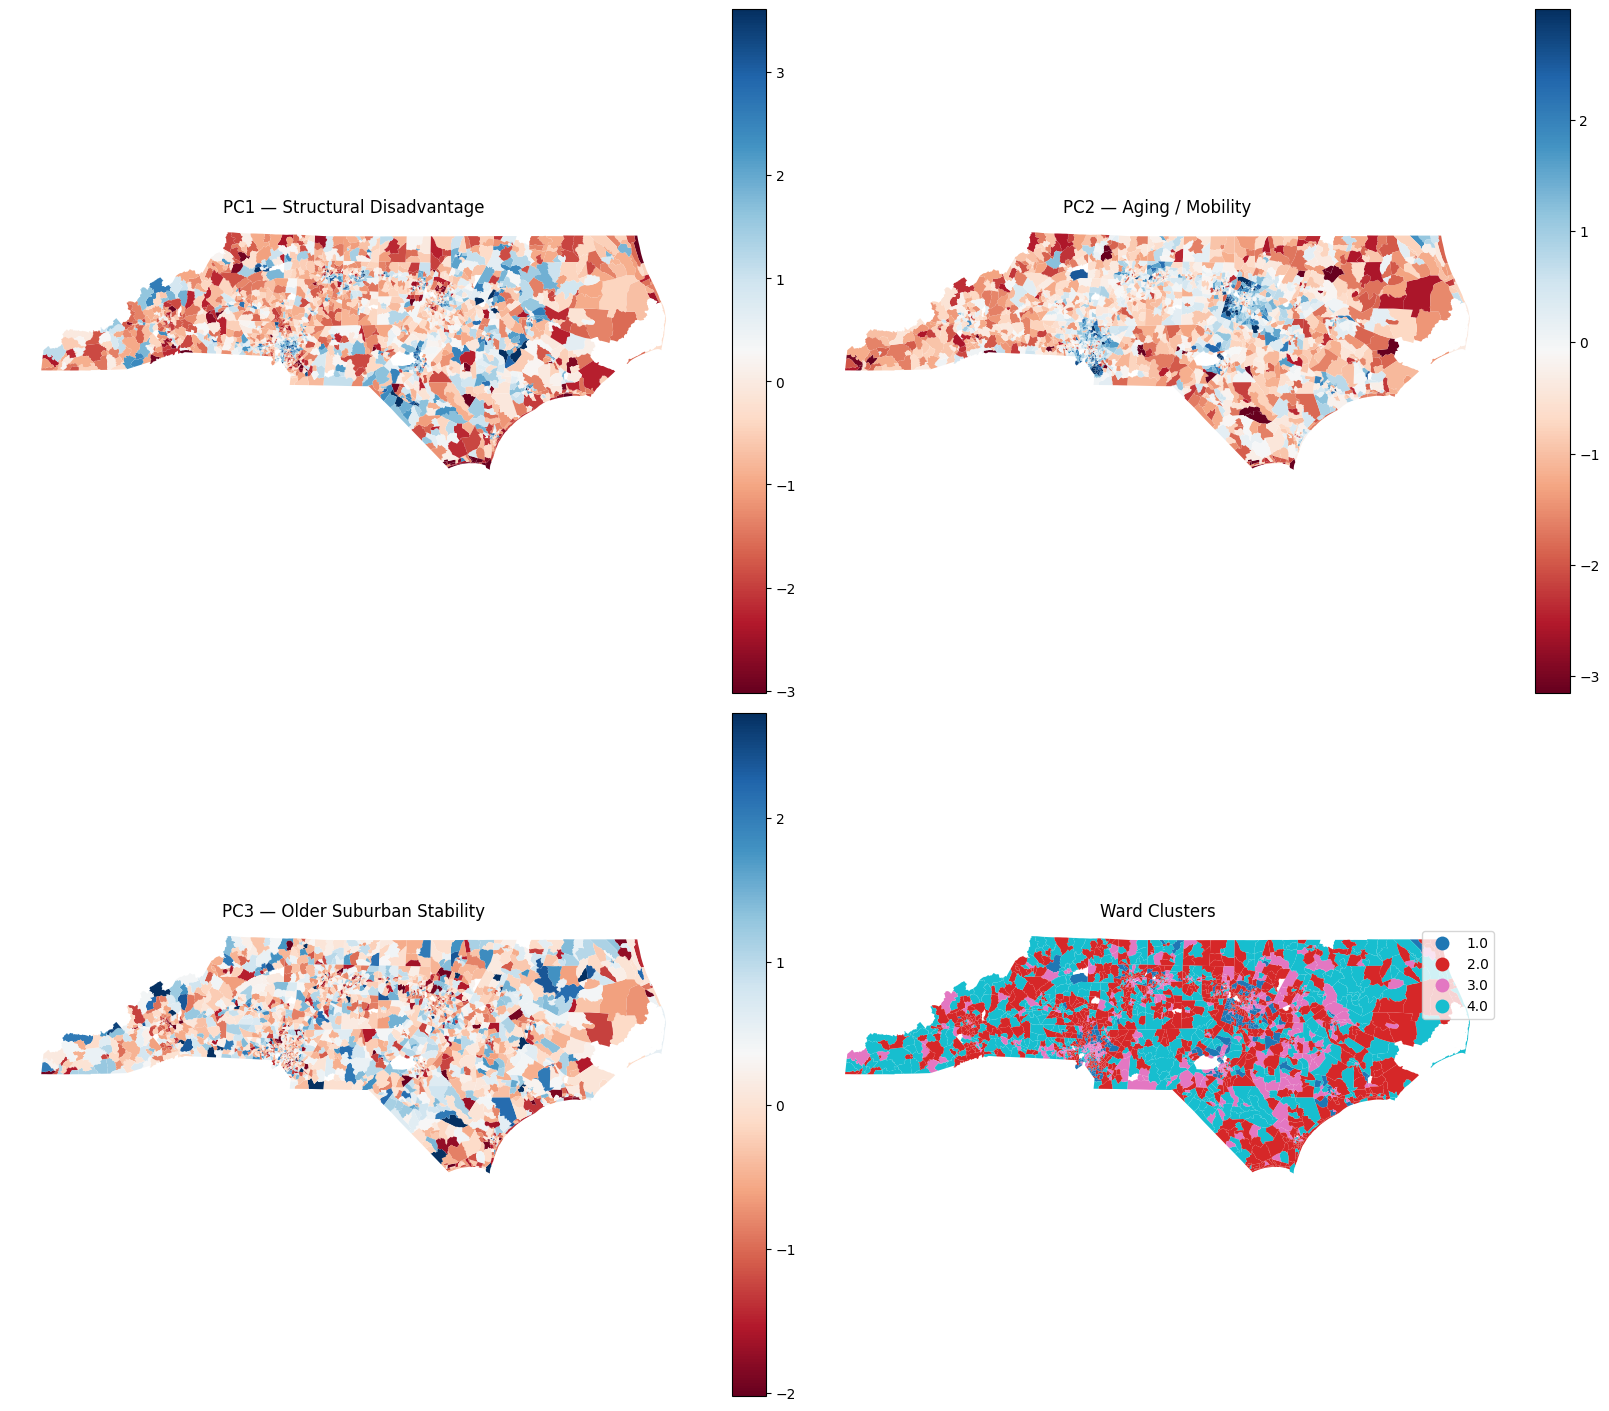

In [ ]:
variables = ['PC1','PC2','PC3','hc_cluster']
titles = ['PC1 — Structural Disadvantage', 'PC2 — Aging / Mobility', 'PC3 — Older Suburban Stability', 'Ward clusters']

fig, axes = plt.subplots(2, 2, figsize=(16, 14), constrained_layout=True)

variables = ['PC1', 'PC2', 'PC3', 'hc_cluster']
titles = [
    'PC1 — Structural Disadvantage',
    'PC2 — Economic advantage/Health Disadvantage',
    'PC3 — Vehicle Access vs Rent Burden',
    'Ward Clusters'
]

# axes is a 2x2 numpy array; flatten to 1D list of axes
axes = axes.ravel()

for i, var in enumerate(variables):
    ax = axes[i]  # <-- HERE IS THE FIX: ax is now a single Axes object

    if var == 'hc_cluster':
        # categorical map
        gdf.plot(
            column=var,
            ax=ax,
            categorical=True,
            legend=True,
            cmap='tab10',
            linewidth=0,
            edgecolor='none'
        )
    else:
        # continuous PCs with diverging colormap
        vmin = gdf[var].quantile(0.01)
        vmax = gdf[var].quantile(0.99)
        gdf.plot(
            column=var,
            ax=ax,
            cmap='RdBu',
            legend=True,
            vmin=vmin,
            vmax=vmax,
            linewidth=0,
            edgecolor='none'
        )

    ax.set_title(titles[i], fontsize=12)
    ax.set_axis_off()

plt.show()

In [ ]:
# ensure geojson exists
geojson = json.loads(gdf.to_json())

# make sure gid exists and matches geojson feature properties
gdf['gid'] = gdf['TRACT'].astype(str)

center = {"lat": 35.5, "lon": -79.0}

def make_plotly_choropleth(var, title, categorical=False):
    if not categorical:
        fig = px.choropleth_mapbox(
            gdf,
            geojson=geojson,
            locations='gid',
            color=var,
            featureidkey='properties.gid',   # matches property name in geojson
            mapbox_style='carto-positron',
            center=center,
            zoom=6,
            opacity=0.7,
            hover_data=['gid','TRACT','PC1','PC2','PC3','hc_cluster'],
            title=title
        )
    else:
        fig = px.choropleth_mapbox(
            gdf,
            geojson=geojson,
            locations='gid',
            color=var,
            featureidkey='properties.gid',
            mapbox_style='carto-positron',
            center=center,
            zoom=6,
            opacity=0.8,
            hover_data=['gid','TRACT','PC1','PC2','PC3','hc_cluster'],
            title=title
        )
    fig.update_layout(margin={"r":0,"t":35,"l":0,"b":0})
    return fig

fig_pc1 = make_plotly_choropleth('PC1', 'PC1 — Structural Disadvantage', categorical=False)
fig_pc2 = make_plotly_choropleth('PC2', 'PC2 — Aging / Mobility', categorical=False)
fig_pc3 = make_plotly_choropleth('PC3', 'PC3 — Older Suburban Stability', categorical=False)
fig_clusters = make_plotly_choropleth('hc_cluster', 'Ward clusters (interactive)', categorical=True)

# show in notebook
fig_pc1.show()
fig_pc2.show()
fig_pc3.show()
fig_clusters.show()

# save HTMLs
fig_pc1.write_html("pc1_map_interactive.html")
fig_pc2.write_html("pc2_map_interactive.html")
fig_pc3.write_html("pc3_map_interactive.html")
fig_clusters.write_html("clusters_map_interactive.html")
print("Saved interactive HTML maps.")

## Merge with outage + weather summaries (tract)

I have:
- tract_outages
- tract_weather

Which are summaries of outages and weather for each tract.

This will help compute:
- Outages per cluster
- Durations per cluster
- Weather exposure per cluster

In [21]:
tract_outages = pd.read_csv('data_processed/PCA_data/tract_outages.csv')
tract_weather = pd.read_csv('data_processed/PCA_data/tract_weather.csv')

# Ensure TRACT columns are strings and zero-padded
socioeconomic_tract_pca_scores['TRACT'] = socioeconomic_tract_pca_scores['TRACT'].astype(str).str.zfill(6)
tract_outages['TRACT'] = tract_outages['TRACT'].astype(str).str.zfill(6)
tract_weather['TRACT'] = tract_weather['TRACT'].astype(str).str.zfill(6)

#MERGE DATSETS
# Merge PCA/cluster -> outages -> weather (left join on PCA tracts)
df = socioeconomic_tract_pca_scores[['TRACT','PC1','PC2','PC3','hc_cluster']].merge(
    tract_outages, on='TRACT', how='left'
).merge(
    tract_weather, on='TRACT', how='left'
)

# Bring in population for rates
pops = tract_socioeconomic_clean[['TRACT','total_population']].copy()
pops['TRACT'] = pops['TRACT'].astype(str).str.zfill(6)
df = df.merge(pops, on='TRACT', how='left')

#DEFINING METRICS TO SUMMARIZE (from tract_outages and tract_weather)
outage_metrics = [
    'total_outages',
    'mean_duration_hours',
    'median_duration_hours',
    'max_duration_hours',
    'total_duration_hours',
    'mean_customers_affected',
    'max_customers_affected',
    'total_customers_affected',
    'total_customer_minutes_out',
    'pct_outages_in_summer',
    'pct_outages_in_winter'
]

weather_metrics = [
    'max_gust_during_outage_days',
    'mean_wind_on_outage_days',
    'total_precip_on_outage_days',
    'mean_soilmoist_on_outage_days',
    'outage_weather_day_count'
]

#keeping metrics that exist
metrics = [m for m in (outage_metrics + weather_metrics) if m in df.columns]

# Per-cluster summary table (mean, median, std, count)
agg_funcs = {m: ['mean','median','std','count'] for m in metrics}
cluster_summary = df.groupby('hc_cluster').agg(agg_funcs)

# flatten MultiIndex columns
cluster_summary.columns = ['_'.join(col).strip() for col in cluster_summary.columns.values]
cluster_summary = cluster_summary.reset_index().sort_values('hc_cluster')

Note that length of tract_outages and tract_weather are the same, but shorter than socioeconomic_tract_pca_scores. Might be worth double checking because means some tracts might be missing weather data primarily.

In [22]:
# Per-cluster rates, outages per 1000 people, customer-minutes per capita
df['outages_per_1000'] = df['total_outages'] / df['total_population'] * 1000
df['customer_minutes_per_capita'] = df['total_customer_minutes_out'] / df['total_population']
per_cluster_rates = df.groupby('hc_cluster')[['outages_per_1000','customer_minutes_per_capita']].agg(['mean','median','std']).reset_index()

# STEP C — Identify outlier clusters

Define outliers as:

    • Tracts where outage frequency/duration is > 2 standard deviations above cluster mean
    • Tracts with high weather exposure but low outages (or vice versa)

In [23]:
# Flag per-tract outliers within each cluster (z-score within cluster)
# Compute z-scores within each hc_cluster for a small set of key metrics:
key_metrics = ['total_outages','total_duration_hours','total_customer_minutes_out','mean_duration_hours','max_gust_during_outage_days']
key_metrics = [m for m in key_metrics if m in df.columns]

# compute z-scores grouped by cluster
def z_within_group(group, cols):
    return group[cols].transform(lambda x: (x - x.mean()) / x.std(ddof=0))

zcols = [f"{m}_z_within_cluster" for m in key_metrics]
df[zcols] = z_within_group(df, key_metrics)

# Flag outliers: absolute z > 2 → unusual
for m, zcol in zip(key_metrics, zcols):
    df[f"{m}_is_outlier"] = df[zcol].abs() > 2

# Create an "outlier score" as sum of flags
outlier_flag_cols = [c for c in df.columns if c.endswith('_is_outlier')]
df['outlier_score'] = df[outlier_flag_cols].sum(axis=1)

# Top standout tracts by outlier_score, tiebreaker by max z magnitude
df['max_abs_z'] = df[zcols].abs().max(axis=1)
outlier_list = df.sort_values(['outlier_score','max_abs_z'], ascending=[False, False]).head(50)

In [24]:
#SAVE RESULTS
cluster_summary.to_csv("data_processed/socieconomic_pca_results/cluster_outage_weather_summary.csv", index=False)
df.to_csv("data_processed/socieconomic_pca_results/tracts_with_clusters_outage_weather.csv", index=False)
outlier_list.to_csv("data_processed/socieconomic_pca_results/top50_standout_tracts.csv", index=False)
print("Saved cluster_outage_weather_summary.csv, tracts_with_clusters_outage_weather.csv, top50_standout_tracts.csv")

Saved cluster_outage_weather_summary.csv, tracts_with_clusters_outage_weather.csv, top50_standout_tracts.csv


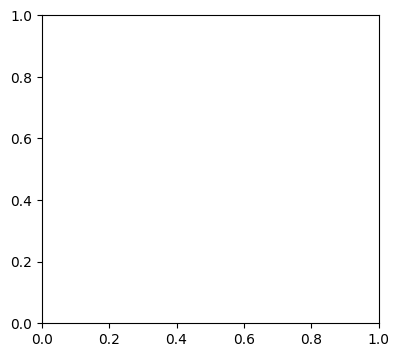

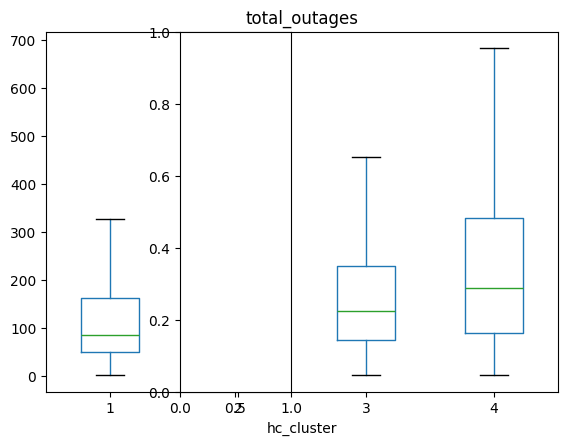

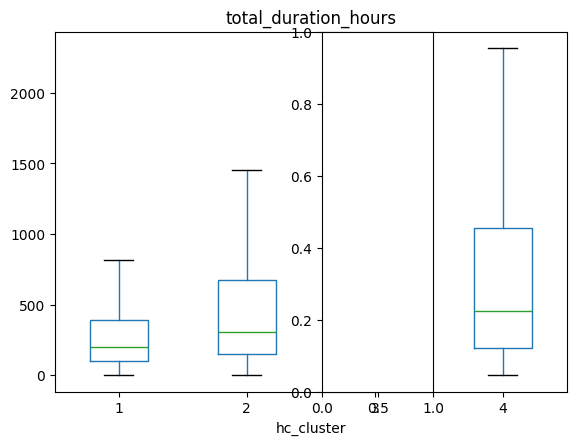

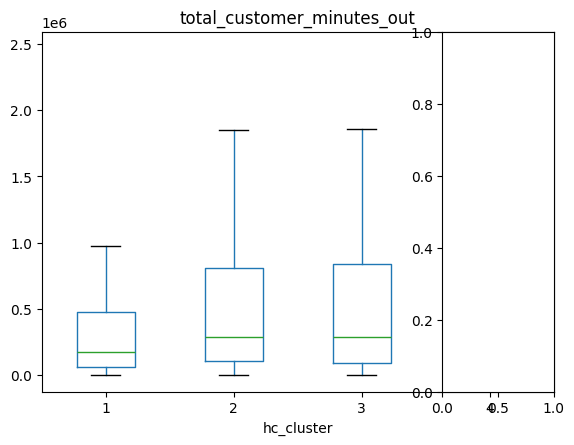

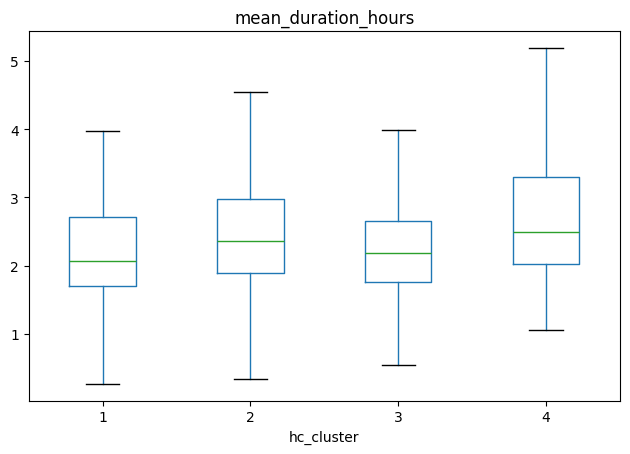

In [25]:
# Quick boxplots for a few key metrics by cluster
plot_metrics = [m for m in ['total_outages','total_duration_hours','total_customer_minutes_out','mean_duration_hours'] if m in df.columns]
n = len(plot_metrics)
plt.figure(figsize=(5*n,4))
for i, m in enumerate(plot_metrics, 1):
    plt.subplot(1, n, i)
    df.boxplot(column=m, by='hc_cluster', grid=False, showfliers=False)
    plt.title(m)
    plt.suptitle('')
plt.tight_layout()
plt.show()